# DS-ROM for 2D Burgers

Test smooth POD-ROM on Burgers data (no gridding). Load validation data, form train/test split, then run hyperparameter optimization (sigma, sigmaD, num_iter).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter as gaussian_filter_gpu
from ezyrb import POD, Database, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from smooth_POD_ROM.post_processing import get_sigma, richardson_lucy2_gpu
from smooth_POD_ROM.reduced_order_model import (
    train_ROM_rw,
    get_predictions_gpu,
    get_improvement,
    L2_error_rw,
)
from scipy.optimize import minimize, Bounds, direct

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.colormaps.get_cmap("plasma")
single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
fw, fh = single_column_in, single_column_in/1.618
single_column_figure = (fw, fh)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [3]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Burger/"

X_val_all = np.load(pth + "X_val.npy").T
mu_val_all = np.load(pth + "mu_val.npy")[:, None]

shape = (257, 257)
x = y = np.linspace(0, 1, 257, endpoint=True)
dx = x[1] - x[0]
sigma, c = 0.003972, 0.9349  # 3.1*dx, 1

# Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
rank = 10
jj = int(np.ceil(len(mu_val_all)/rank))
X_train = X_val_all[::jj]
mu_train = mu_val_all[::jj, :]
print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())

# Restrict validation to mu <= max(mu_train)
is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
mu_val = mu_val_all[is_inside]
X_val = X_val_all[is_inside]

# Test: 20 random snapshots (constant seed)
rng = np.random.default_rng(42)
n_test_want = 20
n_avail = len(mu_val)
inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
mu_test = mu_val_all[inds]
X_test = X_val_all[inds]

print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
print(X_train.shape, X_test.shape, X_val.shape)
print(mu_train.shape, mu_test.shape, mu_val.shape)

rank = len(mu_train)

(10, 1) (10, 66049) [0.  0.9]
(20, 1) (20, 66049) [0.683 0.469]
(10, 66049) (20, 66049) (901, 66049)
(10, 1) (20, 1) (901, 1)


In [4]:
X_grid = np.asarray(x)
Y_grid = np.asarray(y)
X_mesh, Y_mesh = np.meshgrid(X_grid, Y_grid, indexing="ij")

## Mean of training set

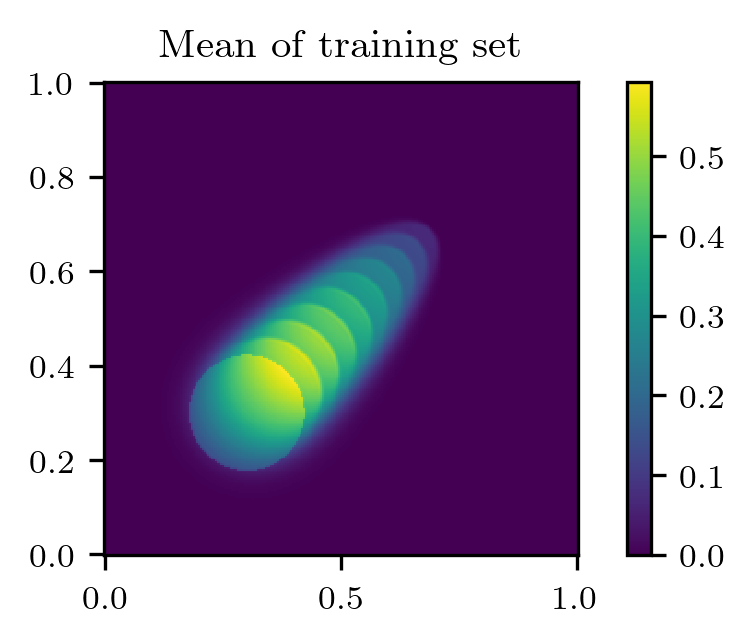

In [5]:
mean_train = np.mean(X_train, axis=0).reshape(shape)

fig, ax = plt.subplots()
cs = ax.pcolormesh(X_mesh, Y_mesh, mean_train)
plt.colorbar(cs, ax=ax)
ax.set_title("Mean of training set")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Case dict and target function

Precomputed `X_train_n`, `X_test_n` (normalized); we smooth training data on GPU and use `get_predictions_gpu` (RL deconvolution uses `richardson_lucy2_gpu`).

In [6]:
n_test = X_test.shape[0]
case = {
    "sigma": 0.01628,
    "c": 0.5617,
    "num_iter": 20,
    "shape": shape,
    "x": x,
    "dx": dx,
    "mode": "reflect",
    "sigmaD": "calc_based_on_distance",
    "mu_train": mu_train,
    "mu_test": mu_test,
    "n_test": n_test,
    "rank": rank
}


# def target_function(case, X_e_n=X_test_n):
#     sgm = case["sigma"] / case["dx"]
#     mode = case["mode"]
#     print(len(mu_train), len(mu__), case["sigma"], case["c"], case["sigmaD"][0], case["num_iter"], end=" ")
#     # GPU smoothing of training set (stack -> gaussian_filter_gpu -> mass conservation -> flatten)
#     X_train_gpu = cp.asarray(X_train_n.reshape(-1, *shape).astype(np.float32))
#     m0 = cp.sum(X_train_gpu, axis=(1, 2), keepdims=True)
#     out = gaussian_filter_gpu(X_train_gpu, sigma=(0, sgm, sgm), truncate=8, mode=mode)
#     m1 = cp.sum(out, axis=(1, 2), keepdims=True)
#     out = out * cp.where(m1 > 0, m0 / m1, 1.0)
#     X_train_n_s = cp.asnumpy(out).reshape(len(X_train_n), -1)
#     #print(mu_train.shape, X_train.shape, X_train_n.shape)
#     my_ROM = train_ROM_rw(mu_train, X_train_n)
#     my_sROM = train_ROM_rw(mu_train, X_train_n_s)
#     X___ROM_n = my_ROM.predict(mu__).snapshots_matrix
#     X___sROM_n, X___sROMs_n = get_predictions_gpu(my_sROM, mu__, **case)
#     # print("train_n, _n_s", np.sum(X_train_n, axis=1), np.sum(X_train_n_s, axis=1))
#     # print("__n rom, srom, dsrom", np.sum(X___ROM_n, axis=1), np.sum(X___sROM_n, axis=1), np.sum(X___sROMs_n, axis=1))
#     # print("train_n, _n_s", np.max(X_train_n, axis=1), np.max(X_train_n_s, axis=1))
#     # print("__n rom, srom, dsrom", np.max(X___ROM_n, axis=1), np.max(X___sROM_n, axis=1), np.max(X___sROMs_n, axis=1))
#     if normalize:
#         X___ROM = scaler.scale_up(X___ROM_n, mu__)
#         X___sROM = scaler.scale_up(X___sROM_n, mu__)
#         X___sROMs = scaler.scale_up(X___sROMs_n, mu__)
#     else:
#         X___ROM = X___ROM_n
#         X___sROM = X___sROM_n
#         X___sROMs = X___sROMs_n
#     # print("_ rom, srom, dsrom", np.sum(X___ROM, axis=1), np.sum(X___sROM, axis=1), np.sum(X___sROMs, axis=1))
#     # print("_ rom, srom, dsrom", np.max(X___ROM, axis=1), np.max(X___sROM, axis=1), np.max(X___sROMs, axis=1))

#     mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
#         X_e_n, X___ROM, X___sROM, X___sROMs, norm=L2_error_rw, scaler=False
#     )
#     print(mean_ROM, mean_sROM, mean_sROMs, improvement)
#     return mean_ROM, mean_sROM, mean_sROMs, X___ROM, X___sROM, X___sROMs

def target_function(case, X_train, mu_, X_e=None):
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    shape = case["shape"]
    mu_train = case["mu_train"]
    print(len(mu_train), len(mu_), case["sigma"], case["c"], case["sigmaD"][0], case["num_iter"], end=" ")
    # GPU smoothing of training set (stack -> gaussian_filter_gpu -> mass conservation -> flatten)
    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    m0 = cp.sum(X_train_gpu, axis=(1, 2), keepdims=True)
    out = gaussian_filter_gpu(X_train_gpu, sigma=(0, sgm, sgm), truncate=8, mode=mode)
    m1 = cp.sum(out, axis=(1, 2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_s = cp.asnumpy(out).reshape(len(X_train), -1)
    #print(mu_train.shape, X_train.shape, X_train.shape)
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    X___ROM = my_ROM.predict(mu_).snapshots_matrix

    u_max = np.interp(mu_, mu_train.ravel(), X_train.max(axis=1)).ravel()
    #u_max = np.ones_like(mu_).ravel()
    
    X___sROM, X___sROMs = get_predictions_gpu(my_sROM, mu_, cmax=u_max, **case)

    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_e, X___ROM, X___sROM, X___sROMs, norm=L2_error_rw, scaler=False
    )
    print(mean_ROM, mean_sROM, mean_sROMs, improvement)
    return mean_ROM, mean_sROM, mean_sROMs, X___ROM, X___sROM, X___sROMs

In [7]:
# single evaluation with current case: target_function(case)

mean_ROM, mean_sROM, mean_sROMs, X_test_ROM, X_test_sROM, X_test_sROMs = target_function(case, X_train, mu_test, X_e=X_test)

10 20 0.01628 0.5617 c 20 0.02448297424782154 0.027707092380334412 0.01858783990485643 -24.07850567211885


In [8]:
e_ROM = L2_error_rw(X_test_ROM, X_test)
e_sROM = L2_error_rw(X_test_sROM, X_test)
e_sROMs = L2_error_rw(X_test_sROMs, X_test)

u_max = np.interp(mu_test, mu_train.ravel(), X_train.max(axis=1)).ravel()

for i in range(len(e_ROM)):
    sgm_est = get_sigma(case["sigma"], mu_test[i][None, ...], mu_train, c=case["c"])
    print(i,mu_test[i], u_max[i], np.max(X_test[i]), np.max(X_test_sROMs[i]), sgm_est, e_ROM[i], e_sROM[i], e_sROMs[i], 100 * e_sROMs[i] / e_ROM[i] - 100)

0 [0.683] 0.8245252558712098 0.8161895452675378 0.8052678835650268 0.01783456092 0.014019341400138283 0.020319035919349464 0.008913939634529643 -36.416844557036626
1 [0.642] 0.8570136220036287 0.8494035892741593 0.8438309405939579 0.02012067992 0.024330654920913786 0.023975453285560566 0.01975070116698921 -18.823799724305033
2 [0.179] 1.1156509091055018 1.1162757203726565 1.0733332127421997 0.01820033996 0.036944488261826364 0.036818705779324896 0.0238452171200195 -35.45663171451193
3 [0.871] 0.7118438092890775 0.7077561970058747 0.6897531507395217 0.018931898040000002 0.01370841275870343 0.01745155050064464 0.008535592679798728 -37.7346390859182
4 [0.755] 0.7764175472709828 0.7742254569117398 0.7764175472709828 0.020395014200000006 0.01991212625967841 0.0207731040515985 0.014454178616459708 -27.410169923796232
5 [0.681] 0.8261100542191328 0.82206847966415 0.7938871039252019 0.01801745044 0.015271860711091127 0.020665260243714866 0.009379695773335939 -38.581840479176364
6 [0.115] 1.115

8 0.021220831972158048 0.024294480167646584 0.024294480167646584 -39.35059866130526


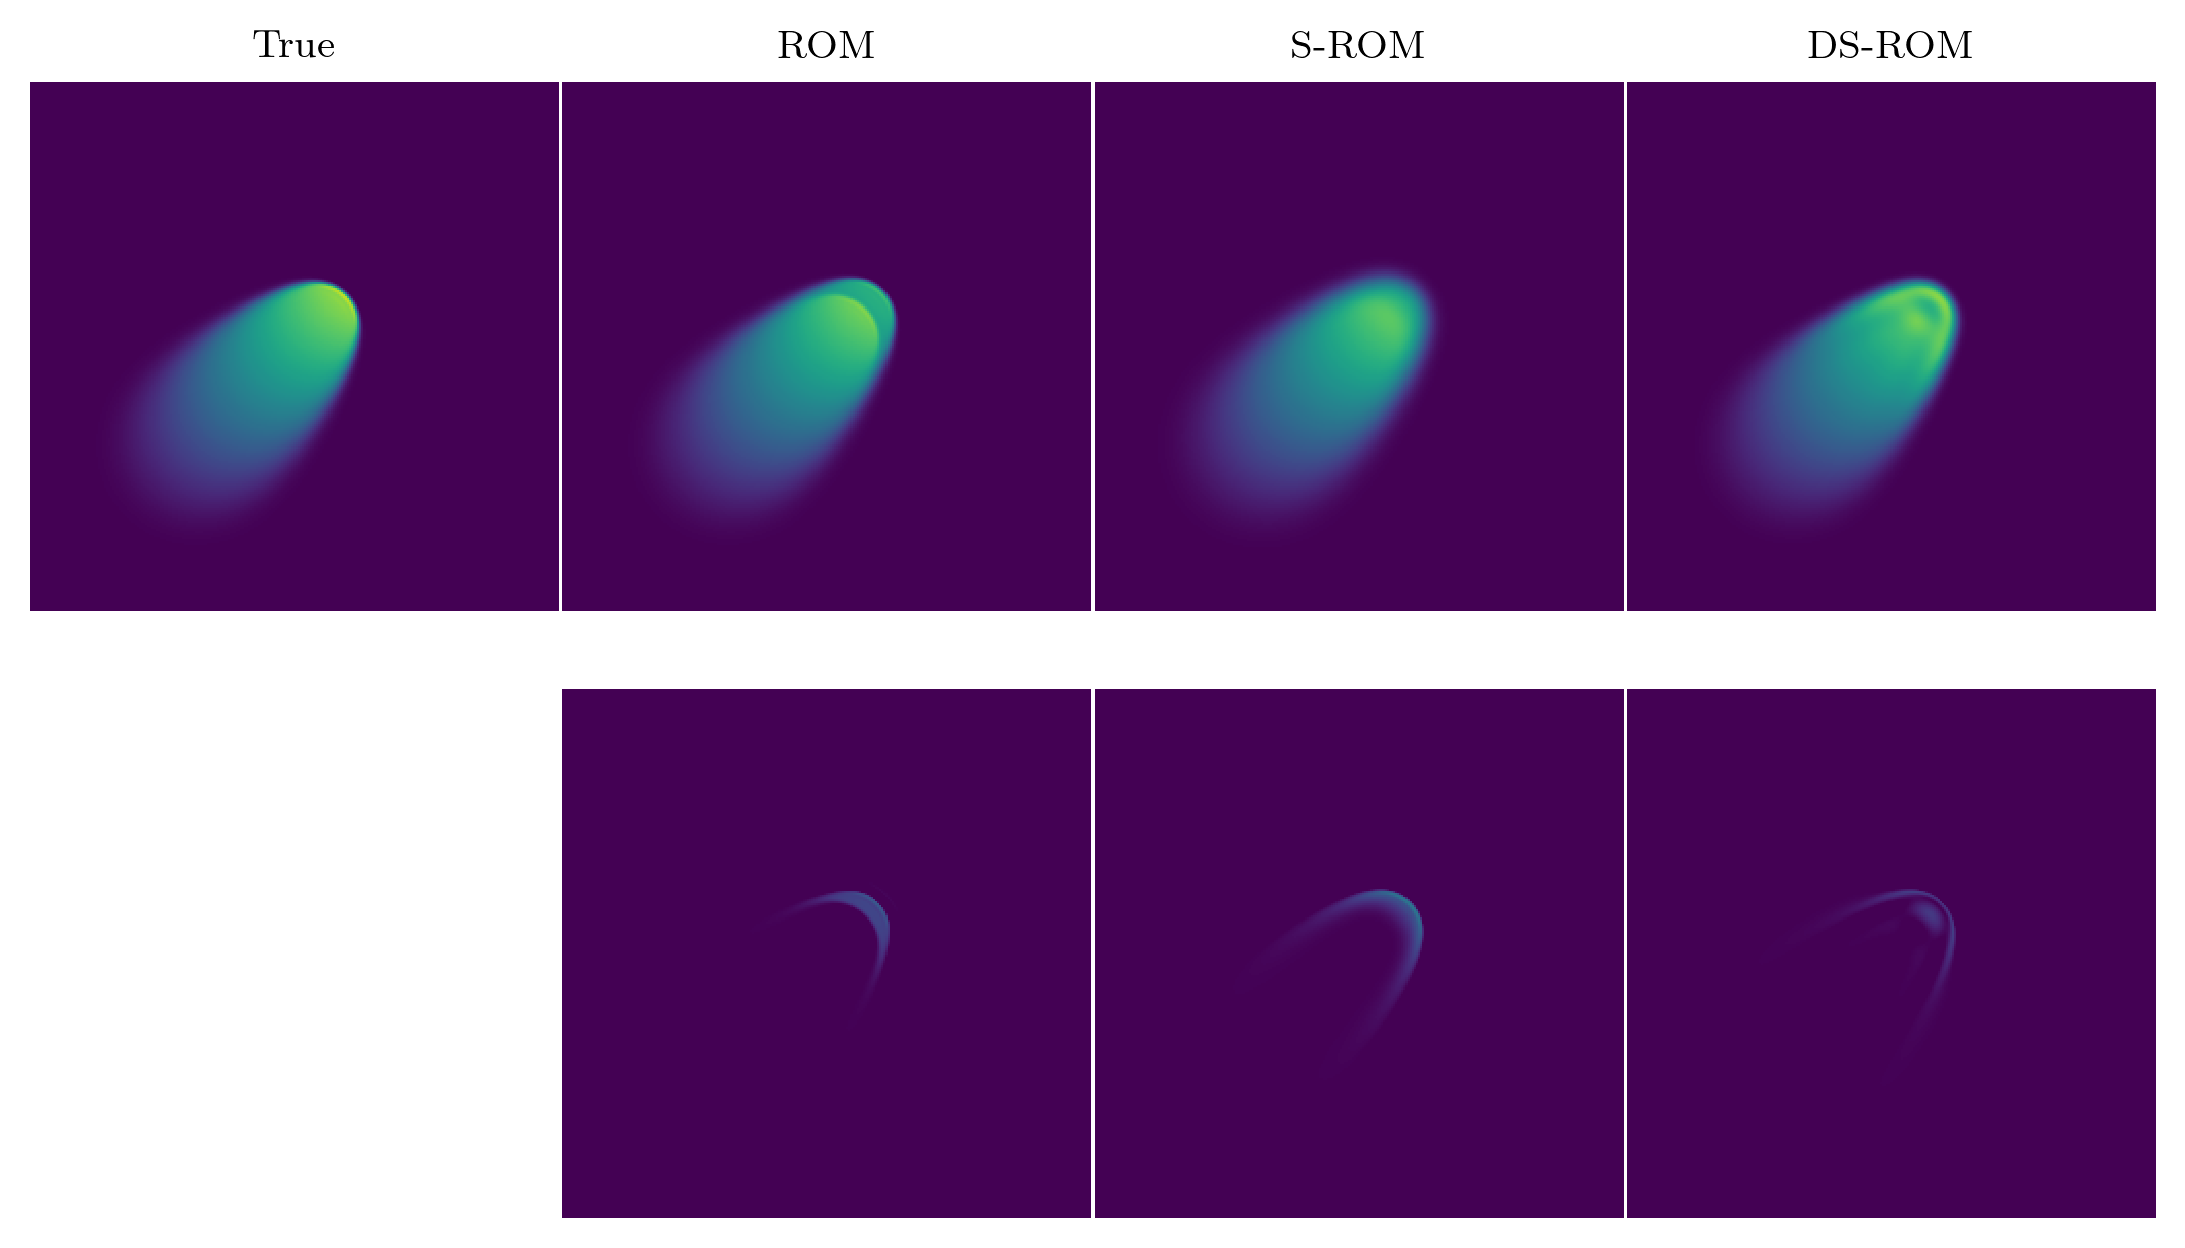

2 0.036944488261826364 0.036818705779324896 0.036818705779324896 -35.45663171451193


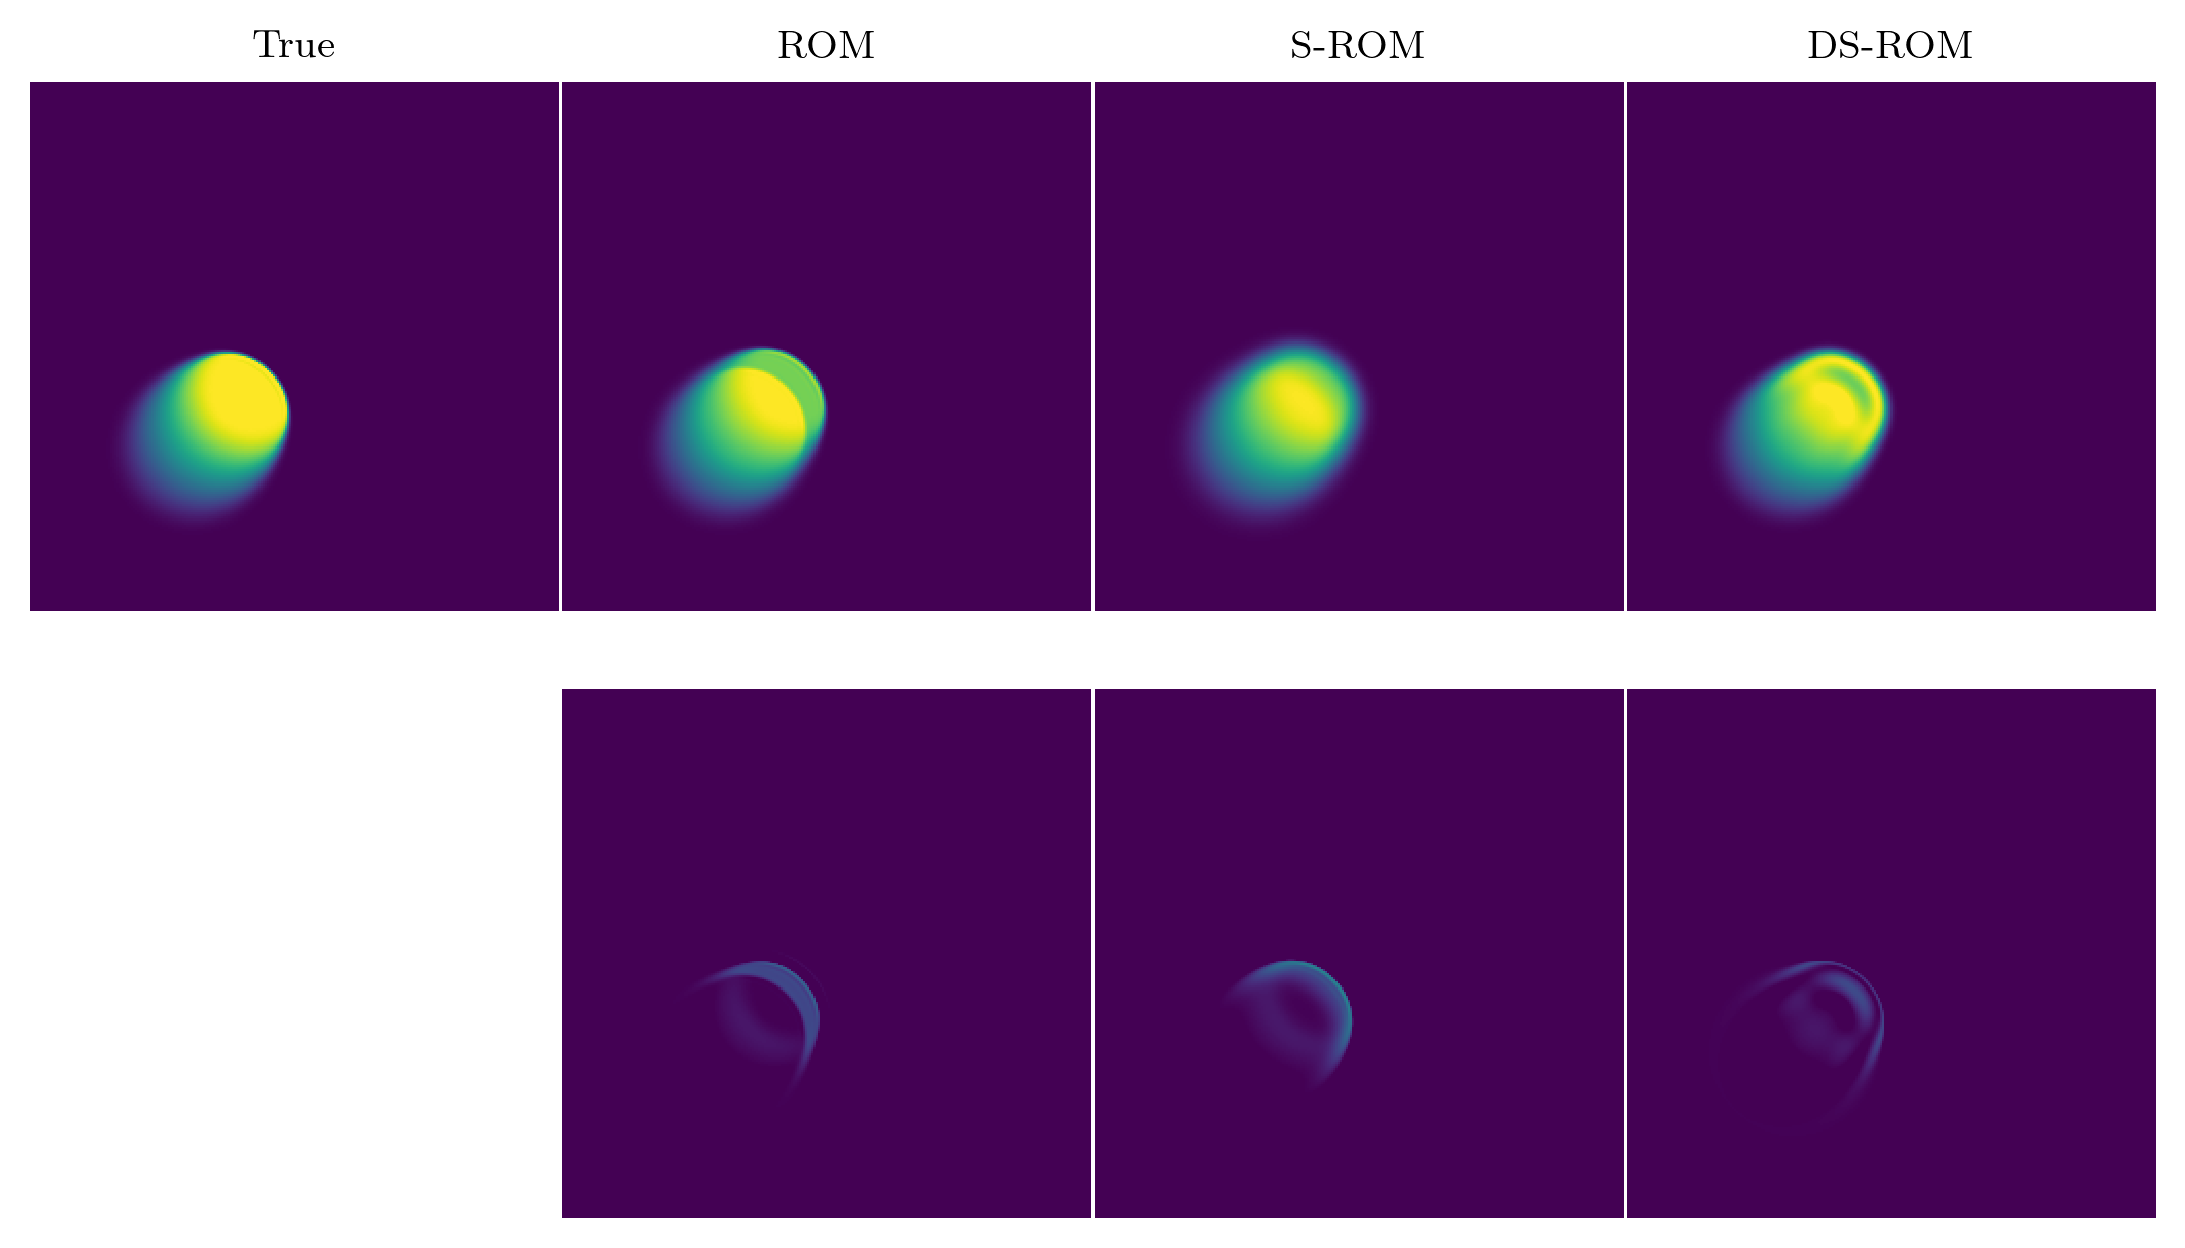

In [9]:
for i in [8, 2]:
    print(i, e_ROM[i], e_sROM[i], e_sROM[i], 100 * e_sROMs[i] / e_ROM[i] - 100)
    fig, axs = plt.subplots(2, 4,  figsize=(single_column_in*2, single_column_in*2/1.618))
    for col, (Z, title) in enumerate([
        (X_test[i], "True"),
        (X_test_ROM[i], "ROM"),
        (X_test_sROM[i], "S-ROM"),
        (X_test_sROMs[i], "DS-ROM"),
    ]):
        ax = axs[0, col]
        ax.pcolormesh(X_mesh, Y_mesh, Z.reshape(shape), vmin=0, vmax=1, shading="nearest", rasterized=True)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_axis_off()
        
        ax = axs[1, col]
        ax.set_aspect("equal")
        ax.set_axis_off()
        if col != 0:
            ax.pcolormesh(X_mesh, Y_mesh, (X_test[i]-Z).reshape(shape), vmin=0, vmax=1, shading="nearest", rasterized=True)
    plt.tight_layout(pad=0.0, w_pad=0.1, h_pad=0.1)
    pth = "../Plots/Burgers2D_ss"+str(i)
    plt.savefig(pth+"_results.pdf")
    plt.show()

## Optimization (sigma, sigmaD)

In [10]:
# def _target_for_optimizer(params):
#     case["sigma"], case["c"], case["num_iter"] = params[0], params[1], int(round(params[2]))
#     case["mu"] = mu_test
#     #case["sigmaD"][:] = params[1]
#     return target_function(case)[2]


# # We need to pass our target into the optimizer; the module's optimize_hyperparameters_3d
# # uses its own target (target_function from the module). So we define a local optimizer
# # that uses our target_function and the same bounds / L-BFGS-B logic.
# from scipy.optimize import minimize, Bounds, direct

# sigma_opt = 0.013
# bounds = ([0.001, 0, 1], [5 * sigma_opt, 5, 200])


# def optimize_burgers(case, method="direct"):
#     #if "sigmaD" not in case or case["sigmaD"] is None:
#     #    case["sigmaD"] = np.zeros((case["n_test"],))

#     # Minimize mean_sROMs (test error after deconvolution)
#     def objective(x):
#         return _target_for_optimizer(x)
#     bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 5, 200])

#     if method == "direct":
#         res = direct(
#             objective,
#             bounds,
#             eps=1e-2,
#             len_tol=0.01,
#         )
#         x_best = res["x"]
#         print("DIRECT result:", x_best, "mean_sROMs (min) =", res["fun"])
#         return x_best

#     starts = [
#         np.array([2.5*sigma_opt, 2.5, 100.0]),
#         parameters
#     ]
#     best_fun = np.inf
#     best_x = None
#     for x0 in starts:
#         res = minimize(
#             objective,
#             x0,
#             method="L-BFGS-B",
#             bounds=list(zip(bounds[0], bounds[1])),
#             options={"maxfun": 80, "ftol": 1e-4},
#         )
#         if res.fun < best_fun:
#             best_fun = res.fun
#             best_x = res.x
#     x_best = best_x
#     print(
#         "L-BFGS-B result: sigma=%.5f sigmaD=%.5f num_iter=%d mean_sROMs (min)=%.6f"
#         % (x_best[0], x_best[1], int(round(x_best[2])), best_fun)
#     )
#     return x_best


# parameters = optimize_burgers(case, method="direct")
# #parameters = optimize_burgers(case, method="L-BFGS-B")

In [11]:
# starts = [
#     np.array([2.5*sigma_opt, 2.5, 100.0]),
#     parameters
# ]
# best_fun = np.inf
# best_x = None
# for x0 in starts:
#     res = minimize(
#         _target_for_optimizer,
#         x0,
#         method="L-BFGS-B",
#         bounds=list(zip(bounds[0], bounds[1])),
#         options={"maxfun": 80, "ftol": 1e-4, "eps": np.array([0.00025, 0.01, 3])},
#     )
#     if res.fun < best_fun:
#         best_fun = res.fun
#         best_x = res.x
# x_best = best_x
# print(
#     "L-BFGS-B result: sigma=%.5f sigmaD=%.5f num_iter=%d mean_sROMs (min)=%.6f"
#     % (x_best[0], x_best[1], int(round(x_best[2])), best_fun)
# )

In [12]:
ranks = [10, 20, 30, 50, 100]

params_opt = [[None] for i in range(len(ranks))]
for i, rank in enumerate(ranks):
    #for num_iter in [10, 20, 30, 50, 75, 100]:
        num_iter = 20
        jj = int(np.ceil(len(mu_val_all)/rank))
        # Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
        print(len(mu_val_all), np.arange(len(mu_val_all))[::jj])
        X_train = X_val_all[::jj]
        mu_train = mu_val_all[::jj, :]
        print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())
        # Restrict validation to mu <= max(mu_train)
        is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
        mu_val = mu_val_all[is_inside]
        X_val = X_val_all[ is_inside]
        # Test: 20 random snapshots (constant seed)
        rng = np.random.default_rng(42)
        n_test_want = 20
        n_avail = len(mu_val)
        inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
        mu_test = mu_val_all[inds]
        X_test = X_val_all[inds]

        #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
        print(X_train.shape, X_test.shape, X_val.shape)
        print(mu_train.shape, mu_test.shape, mu_val.shape)
        
        #rank = len(mu_train)
       # print(rank, 2 * sigma_opt)
        def _target2(params):
            case["mu_train"] = mu_train
            case["sigma"], case["c"] = params[0], params[1]
            return target_function(case, X_train, mu_test, X_e=X_test)[2]
        
        def _target3(params):
            case["mu_train"] = mu_train
            case["sigma"], case["c"], case["num_iter"] = params[0], params[1], int(round(params[2]))
            return target_function(case, X_train, mu_test, X_e=X_test)[2]
        sigma_opt = 0.23/rank
        bounds2 = Bounds([0.001, 0], [2 * sigma_opt, 3])
        
        #bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 5, 200])
        case["num_iter"] = num_iter
        res = direct(_target2, bounds2, eps=1e-2, len_tol=0.01)
        x_best = res["x"]
        params_opt[i] = x_best
        case["sigma"], case["c"] = x_best[0], x_best[1]
        target_function(case, X_train, mu_test, X_e=X_test)
        print("DIRECT result:", x_best, "mean_sROMs (min) =", res["fun"])
    
        #bounds3 = ([0.001, 0, 1], [5 * sigma_opt, 5, 200])
        #res = direct(_target2, bounds2, eps=1e-2, len_tol=0.01)

print(params_opt)

1000 [  0 100 200 300 400 500 600 700 800 900]
(10, 1) (10, 66049) [0.  0.9]
(10, 66049) (20, 66049) (901, 66049)
(10, 1) (20, 1) (901, 1)
10 20 0.0235 1.5 c 20 0.02448297424782154 0.033554957350761506 0.03430772892024103 40.128926220202544
10 20 0.0385 1.5 c 20 0.02448297424782154 0.046127869026669224 0.04867940271128001 98.82961203380523
10 20 0.0085 1.5 c 20 0.02448297424782154 0.02316679462674953 0.022584163408633152 -7.755637938300481
10 20 0.0235 2.5 c 20 0.02448297424782154 0.033554957350761506 0.046077117914686314 88.20065506863892
10 20 0.0235 0.5 c 20 0.02448297424782154 0.033554957350761506 0.0217247241509212 -11.2659927220475
10 20 0.0385 0.5 c 20 0.02448297424782154 0.046127869026669224 0.03206649551640901 30.97467322321856
10 20 0.0085 0.5 c 20 0.02448297424782154 0.02316679462674953 0.023711632217193523 -3.1505242084574263
10 20 0.0385 2.5 c 20 0.02448297424782154 0.046127869026669224 0.06444173325730963 163.21039513017325
10 20 0.0085 2.5 c 20 0.02448297424782154 0.0231

In [13]:
#params_opt = [[0.02016667, 0.35185185], [0.01145679, 0.5       ], [0.00846159, 0.53703704], [0.00628107, 0.35185185],  [0.00459259, 0.14197531] ]  # n_iter = 50?

# testing

1000 [  0 100 200 300 400 500 600 700 800 900]
(10, 1) (10, 66049) [0.  0.9]
(10, 66049) (20, 66049) (901, 66049)
(10, 1) (20, 1) (901, 1)
10 901 0.016277777777777776 0.5617283950617284 c 20 0.025937242937674604 0.029540234914359923 0.02289616938509431 -11.724737127565106


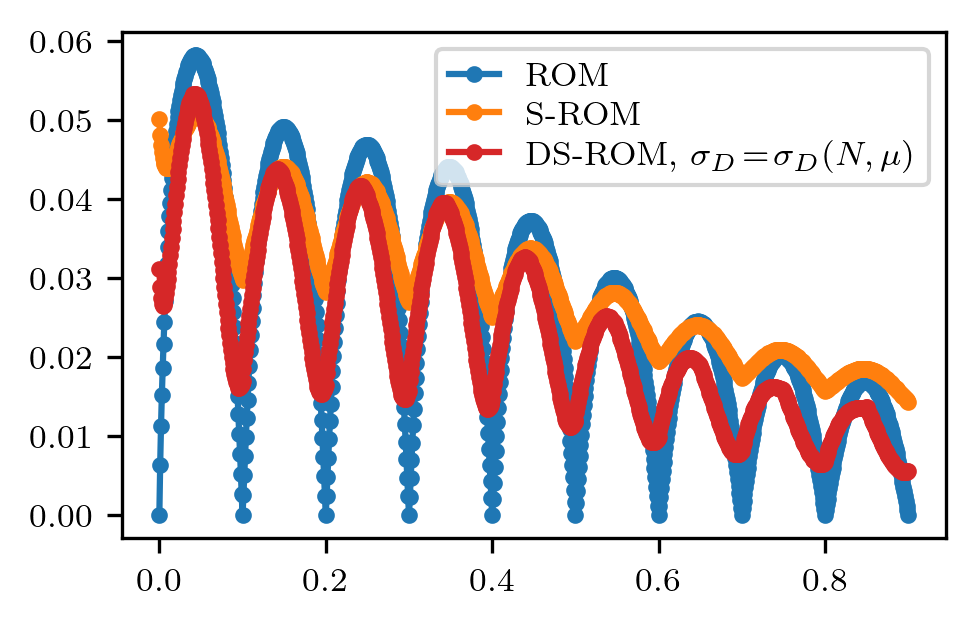

1000 [  0  50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850
 900 950]
(20, 1) (20, 66049) [0.   0.95]
(20, 66049) (20, 66049) (951, 66049)
(20, 1) (20, 1) (951, 1)
20 951 0.009102880658436212 0.7962962962962963 c 20 0.014217327285570307 0.017433940382226586 0.011464439508898906 -19.36290641255343


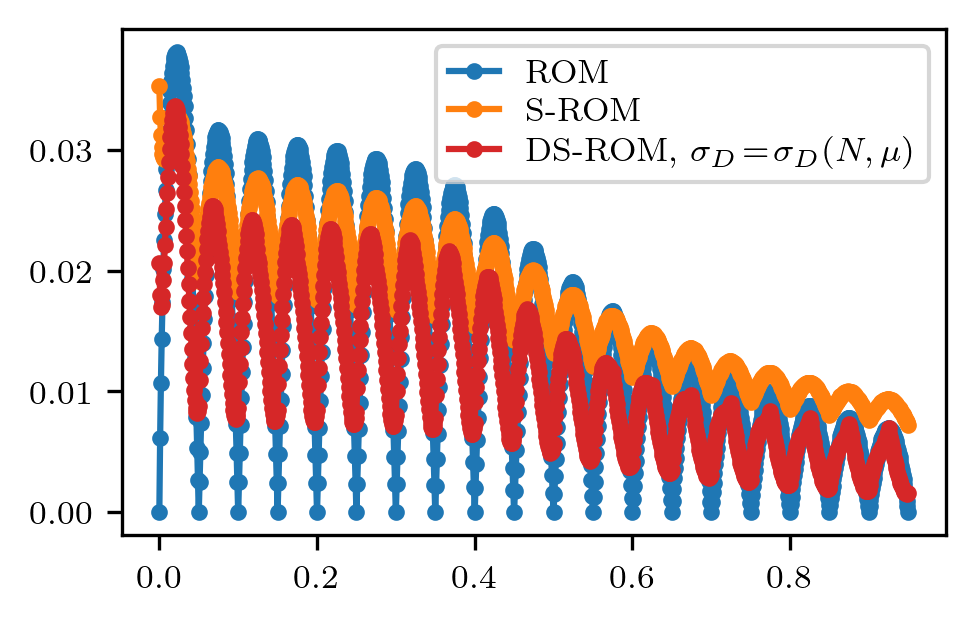

1000 [  0  34  68 102 136 170 204 238 272 306 340 374 408 442 476 510 544 578
 612 646 680 714 748 782 816 850 884 918 952 986]
(30, 1) (30, 66049) [0.    0.986]
(30, 66049) (20, 66049) (987, 66049)
(30, 1) (20, 1) (987, 1)
30 987 0.006574074074074074 0.8950617283950618 c 20 0.009494617639834089 0.012500268143935912 0.007086223329936228 -25.3658904577009


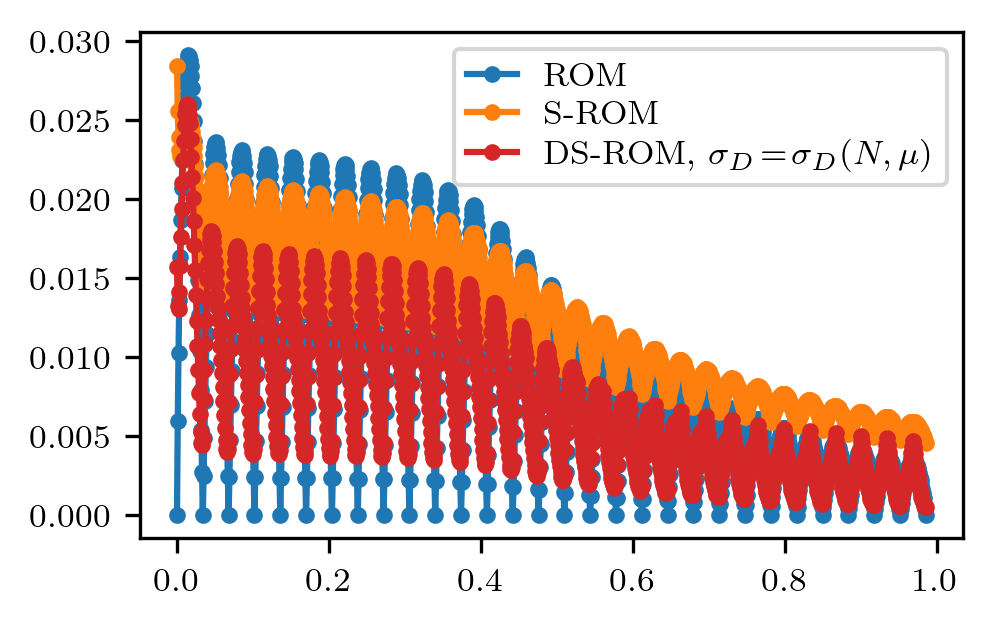

1000 [  0  20  40  60  80 100 120 140 160 180 200 220 240 260 280 300 320 340
 360 380 400 420 440 460 480 500 520 540 560 580 600 620 640 660 680 700
 720 740 760 780 800 820 840 860 880 900 920 940 960 980]
(50, 1) (50, 66049) [0.   0.98]
(50, 66049) (20, 66049) (981, 66049)
(50, 1) (20, 1) (981, 1)
50 981 0.004863786008230453 0.5864197530864198 c 20 0.004868774014685039 0.008442843530681973 0.0033128854771910165 -31.956474726516404


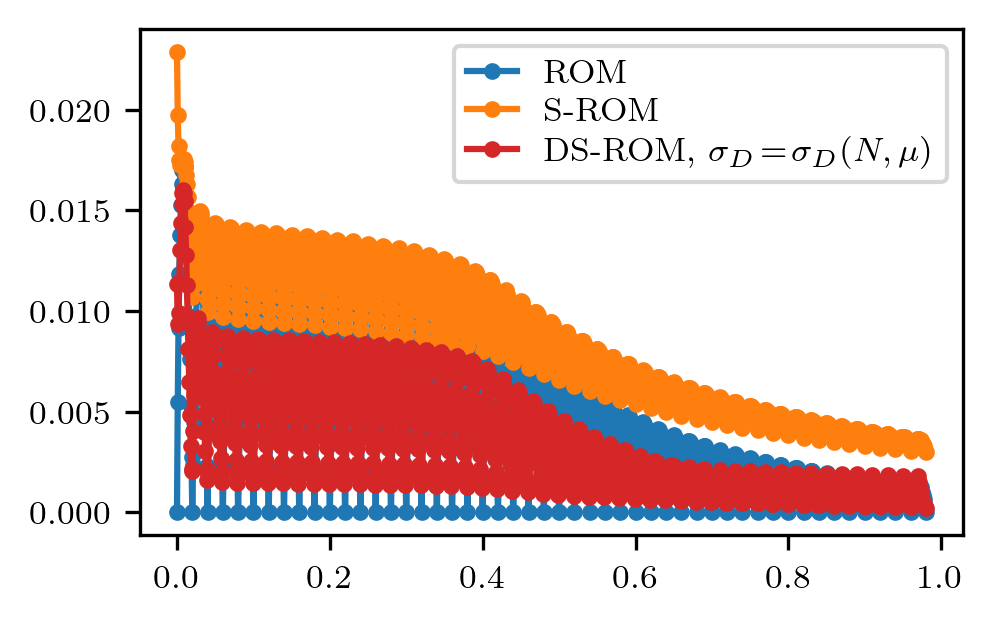

1000 [  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350
 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 510 520 530
 540 550 560 570 580 590 600 610 620 630 640 650 660 670 680 690 700 710
 720 730 740 750 760 770 780 790 800 810 820 830 840 850 860 870 880 890
 900 910 920 930 940 950 960 970 980 990]
(100, 1) (100, 66049) [0.   0.99]
(100, 66049) (20, 66049) (991, 66049)
(100, 1) (20, 1) (991, 1)
100 991 0.004207407407407408 0.2407407407407408 c 20 0.0014871148575102914 0.006078080031211387 0.0010761012307334704 -27.638324282828748


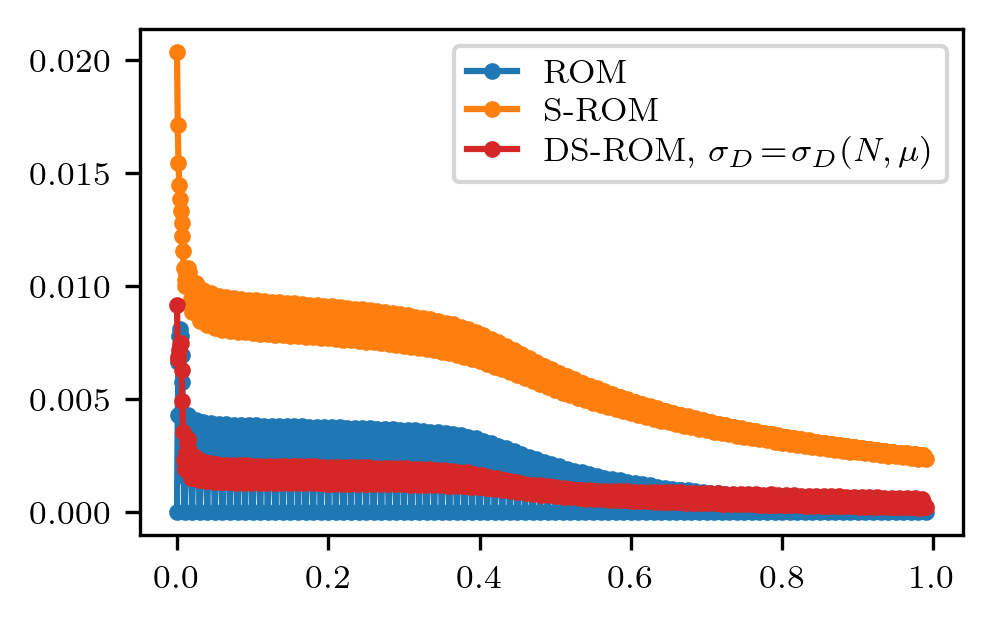

In [14]:
for i, rank in enumerate(ranks):
    case["sigma"], case["c"] = params_opt[i][0], params_opt[i][1]
    case["num_iter"] = 20
    jj = int(np.ceil(len(mu_val_all)/rank))
    # Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
    print(len(mu_val_all), np.arange(len(mu_val_all))[::jj])
    X_train = X_val_all[::jj]
    mu_train = mu_val_all[::jj, :]
    print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())
    # Restrict validation to mu <= max(mu_train)
    is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
    mu_val = mu_val_all[is_inside]
    X_val = X_val_all[is_inside]
    # Test: 20 random snapshots (constant seed)
    rng = np.random.default_rng(42)
    n_test_want = 20
    n_avail = len(mu_val)
    inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
    mu_test = mu_val[inds]
    X_test = X_val[inds]

    
    #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
    print(X_train.shape, X_test.shape, X_val.shape)
    print(mu_train.shape, mu_test.shape, mu_val.shape)

    case["mu_train"] = mu_train
    mean_ROM, mean_sROM, mean_sROMs, X_val_ROM, X_val_sROM, X_val_sROMs = target_function(case, X_train, mu_val, X_e=X_val)
    e_ROM = L2_error_rw(X_val_ROM, X_val)
    e_sROM = L2_error_rw(X_val_sROM, X_val)
    e_sROMs = L2_error_rw(X_val_sROMs, X_val)
    fig, ax = plt.subplots()
    ax.plot(mu_val.ravel(), e_ROM.ravel(), "C0o-", ms=3, label=r"ROM")
    ax.plot(mu_val.ravel(), e_sROM.ravel(), "C1o-", ms=3, label=r"S-ROM")
    ax.plot(mu_val.ravel(), e_sROMs.ravel(), "C3o-", ms=3, label=r"DS-ROM, $\sigma_D\!=\!\sigma_D(N, \mu)$")  #  (\sigma_S, c)
    plt.legend()
    plt.show()

# DS-ROM + projection: best coefficients are assumed to be known

In [15]:
def smoothen_GPU(X_train, shape, sgm, mode):
    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    m0 = cp.sum(X_train_gpu, axis=(1, 2), keepdims=True)
    out = gaussian_filter_gpu(X_train_gpu, sigma=(0, sgm, sgm), truncate=8, mode=mode)
    m1 = cp.sum(out, axis=(1, 2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_s = cp.asnumpy(out).reshape(len(X_train), -1)
    return X_train_s
    

def target_function_best_coeff(case, X_train, mu_, X_e=None):
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    shape = case["shape"]
    mu_train = case["mu_train"]
    sigma = case["sigma"]
    c = case["c"]
    x = case["x"]
    num_iter = case["num_iter"]
    
    print(len(mu_train), len(mu_), case["sigma"], case["c"], case["sigmaD"][0], case["num_iter"], end=" ")
    X_train_s = smoothen_GPU(X_train, shape, sgm, mode)
    #print(mu_train.shape, X_train.shape, X_train.shape)
    U1, S, VT = np.linalg.svd(X_train.T, full_matrices=False)
    U2, S, VT = np.linalg.svd(X_train_s.T, full_matrices=False)

    # we assume we know the exact coefficients. here we compute them using the exact solution (U2.T @X_test_s.T)
    X_e_s = smoothen_GPU(X_e, shape, sgm, mode)
    X___sROM = (U2 @ (U2.T @X_e_s.T)).T
    X___ROM = (U1 @ (U1.T @X_e.T)).T
    
    #my_ROM = train_ROM_rw(mu_train, X_train)
    #my_sROM = train_ROM_rw(mu_train, X_train_s)
    #X___ROM = my_ROM.predict(mu_).snapshots_matrix
    #print(mu_.shape, mu_train.shape, X_train.shape)
    u_max = np.interp(mu_, mu_train.ravel(), X_train.max(axis=1)).ravel()
    #u_max = np.ones_like(mu_).ravel()

    cmax = u_max
    sigmaD = case["sigmaD"]
    deconvolved = np.empty_like(X___sROM)
    # Transfer all data to GPU once
    data_gpu = cp.asarray(X___sROM.astype(np.float32))
    for j in range(len(mu_)):
        if isinstance(sigmaD, np.ndarray):
            sgm_est = sigmaD[j]
        elif sigmaD == "calc_based_on_distance":
            sgm_est = get_sigma(sigma, mu_[j][None, ...], mu_train, c=c)
        else:
            raise ValueError("unknown method for sigmaD.")
        res = richardson_lucy2_gpu(x, data_gpu[j].reshape(shape), sgm_est, num_iter, mode=mode, monitor_convergence=False, clip_max=cmax[j])[0].reshape(deconvolved[j].shape)
        deconvolved[j] = res
    X___sROMs = deconvolved


    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_e, X___ROM, X___sROM, X___sROMs, norm=L2_error_rw, scaler=False
    )
    print(mean_ROM, mean_sROM, mean_sROMs, improvement)
    return mean_ROM, mean_sROM, mean_sROMs, X___ROM, X___sROM, X___sROMs

In [16]:
ranks = [10, 20, 30, 50, 100]
case["num_iter"] = num_iter = 20
params_opt_best_coeff = [[None] for i in range(len(ranks))]
for i, rank in enumerate(ranks):
    jj = int(np.ceil(len(mu_val_all)/rank))
    # Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
    print(len(mu_val_all), np.arange(len(mu_val_all))[::jj])
    X_train = X_val_all[::jj]
    mu_train = mu_val_all[::jj, :]
    print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())
    # Restrict validation to mu <= max(mu_train)
    is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
    mu_val = mu_val_all[is_inside]
    X_val = X_val_all[ is_inside]
    # Test: 20 random snapshots (constant seed)
    rng = np.random.default_rng(42)
    n_test_want = 20
    n_avail = len(mu_val)
    inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
    mu_test = mu_val_all[inds]
    X_test = X_val_all[inds]


    def _target2(params):
        case["mu_train"] = mu_train
        case["sigma"], case["c"] = params[0], params[1]
        return target_function_best_coeff(case, X_train, mu_test, X_e=X_test)[2]

    sigma_opt = 0.23/rank
    bounds2 = Bounds([0.001, 0], [2 * sigma_opt, 3])
    
    #bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 5, 200])
    case["num_iter"] = num_iter
    res = direct(_target2, bounds2, eps=1e-2, len_tol=0.01)
    x_best = res["x"]
    params_opt_best_coeff[i] = x_best
    case["sigma"], case["c"] = x_best[0], x_best[1]
    target_function_best_coeff(case, X_train, mu_test, X_e=X_test)
    print("DIRECT result:", x_best, "mean_sROMs (min) =", res["fun"])
print(params_opt_best_coeff)

1000 [  0 100 200 300 400 500 600 700 800 900]
(10, 1) (10, 66049) [0.  0.9]
10 20 0.0235 1.5 c 20 0.024023781330431836 0.031009441761288704 0.0363428928136939 51.27881957390687
10 20 0.0385 1.5 c 20 0.024023781330431836 0.04448384910705779 0.04959456134359942 106.43944706895957
10 20 0.0085 1.5 c 20 0.024023781330431836 0.021201919193513795 0.018487032753858216 -23.04694877304769
10 20 0.0235 2.5 c 20 0.024023781330431836 0.031009441761288704 0.04779135474083921 98.93352375922638
10 20 0.0235 0.5 c 20 0.024023781330431836 0.031009441761288704 0.02249836128882007 -6.349625067888283
10 20 0.0085 2.5 c 20 0.024023781330431836 0.021201919193513795 0.023078011159553997 -3.9368081063899467
10 20 0.0085 0.5 c 20 0.024023781330431836 0.021201919193513795 0.017579657600655062 -26.823936003836977
10 20 0.0385 2.5 c 20 0.024023781330431836 0.04448384910705779 0.06500789598859744 170.59810066723122
10 20 0.0385 0.5 c 20 0.024023781330431836 0.04448384910705779 0.03241522232126051 34.9297259886349

## testing



In [17]:
#params_opt_best_coeff = [np.array([0.01664815, 0.00617284]), np.array([0.0101893 , 0.00617284]), np.array([0.00781276, 0.0308642 ]), np.array([0.00520123, 0.00617284]), np.array([0.00106667, 0.08024691])]

1000 [  0 100 200 300 400 500 600 700 800 900]
(10, 1) (10, 66049) [0.  0.9]
(10, 66049) (20, 66049) (901, 66049)
(10, 1) (20, 1) (901, 1)
10 901 0.016648148148148148 0.006172839506172921 c 20 0.025564767546742424 0.027363308716227035 0.016415955214931787 -35.78680038878906


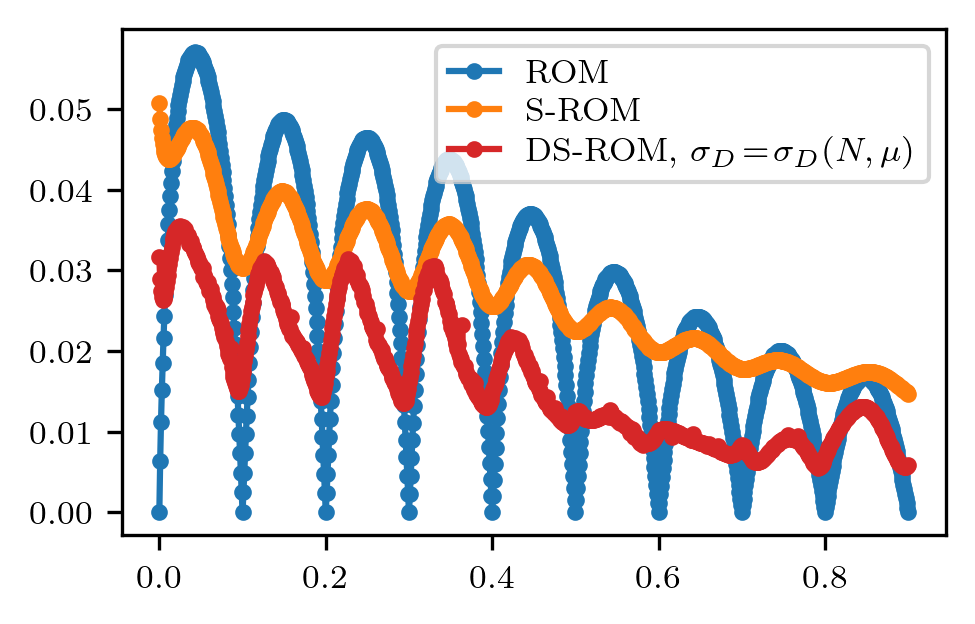

1000 [  0  50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850
 900 950]
(20, 1) (20, 66049) [0.   0.95]
(20, 66049) (20, 66049) (951, 66049)
(20, 1) (20, 1) (951, 1)
20 951 0.010189300411522634 0.006172839506172921 c 20 0.013827741791782033 0.016609559455274744 0.006902996536330699 -50.078641615703155


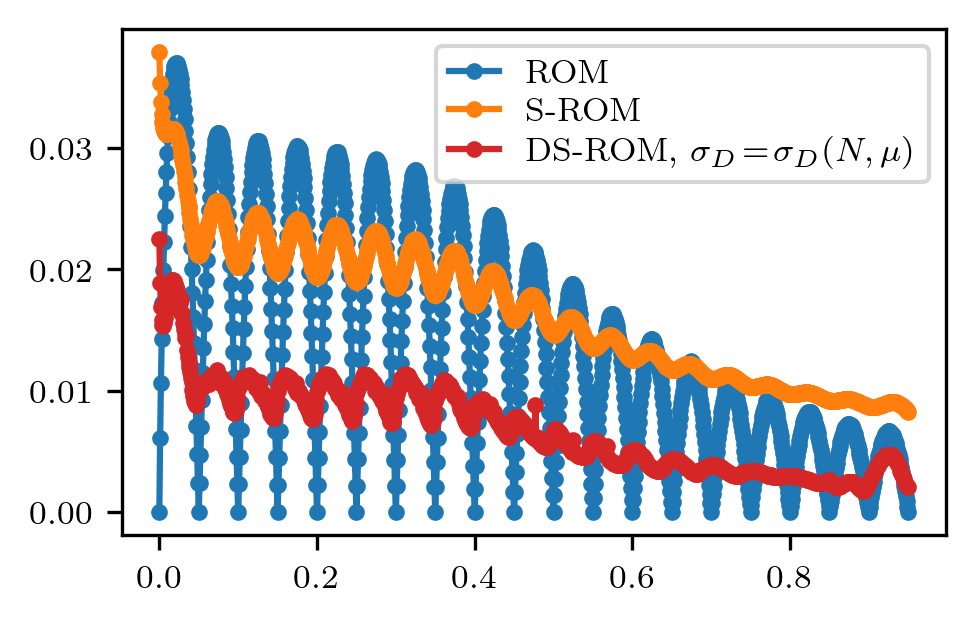

1000 [  0  34  68 102 136 170 204 238 272 306 340 374 408 442 476 510 544 578
 612 646 680 714 748 782 816 850 884 918 952 986]
(30, 1) (30, 66049) [0.    0.986]
(30, 66049) (20, 66049) (987, 66049)
(30, 1) (20, 1) (987, 1)
30 987 0.00781275720164609 0.03086419753086428 c 20 0.008997889284253808 0.012274777874814088 0.004124464605303296 -54.161865355233296


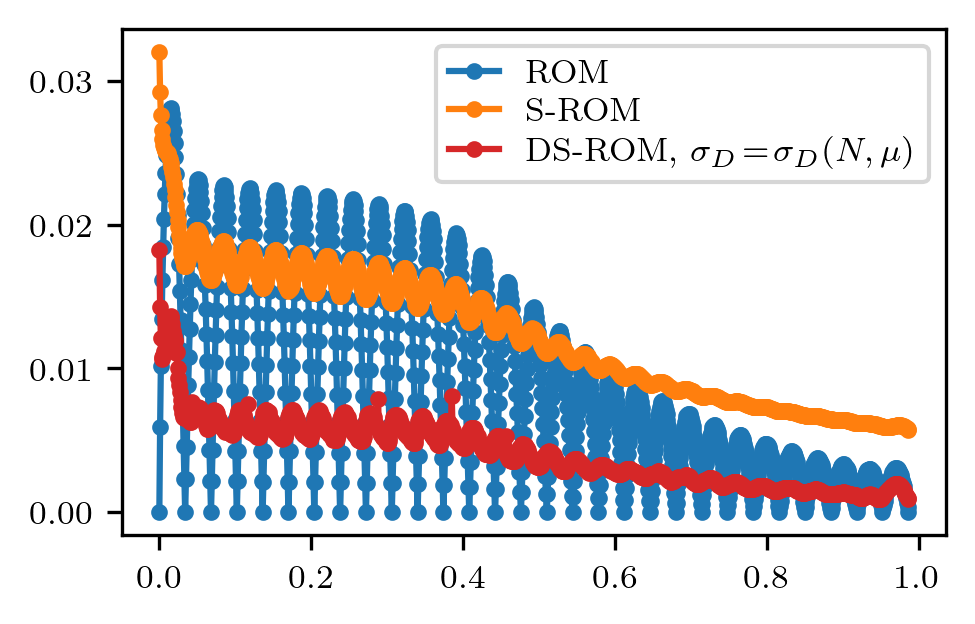

1000 [  0  20  40  60  80 100 120 140 160 180 200 220 240 260 280 300 320 340
 360 380 400 420 440 460 480 500 520 540 560 580 600 620 640 660 680 700
 720 740 760 780 800 820 840 860 880 900 920 940 960 980]
(50, 1) (50, 66049) [0.   0.98]
(50, 66049) (20, 66049) (981, 66049)
(50, 1) (20, 1) (981, 1)
50 981 0.005201234567901235 0.006172839506172921 c 20 0.004094552246891306 0.0076332866744592805 0.0019716835013965745 -51.84617553986447


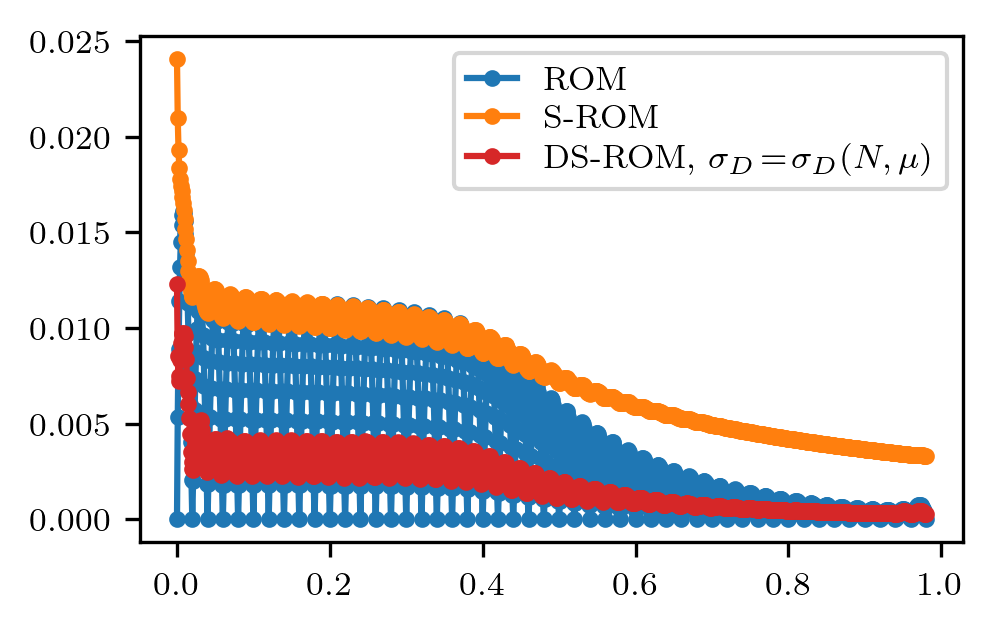

1000 [  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350
 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 510 520 530
 540 550 560 570 580 590 600 610 620 630 640 650 660 670 680 690 700 710
 720 730 740 750 760 770 780 790 800 810 820 830 840 850 860 870 880 890
 900 910 920 930 940 950 960 970 980 990]
(100, 1) (100, 66049) [0.   0.99]
(100, 66049) (20, 66049) (991, 66049)
(100, 1) (20, 1) (991, 1)
100 991 0.0010666666666666667 0.08024691358024699 c 20 0.0002802552762846712 0.0002840438845729449 0.0005506081612516522 96.4666530282799


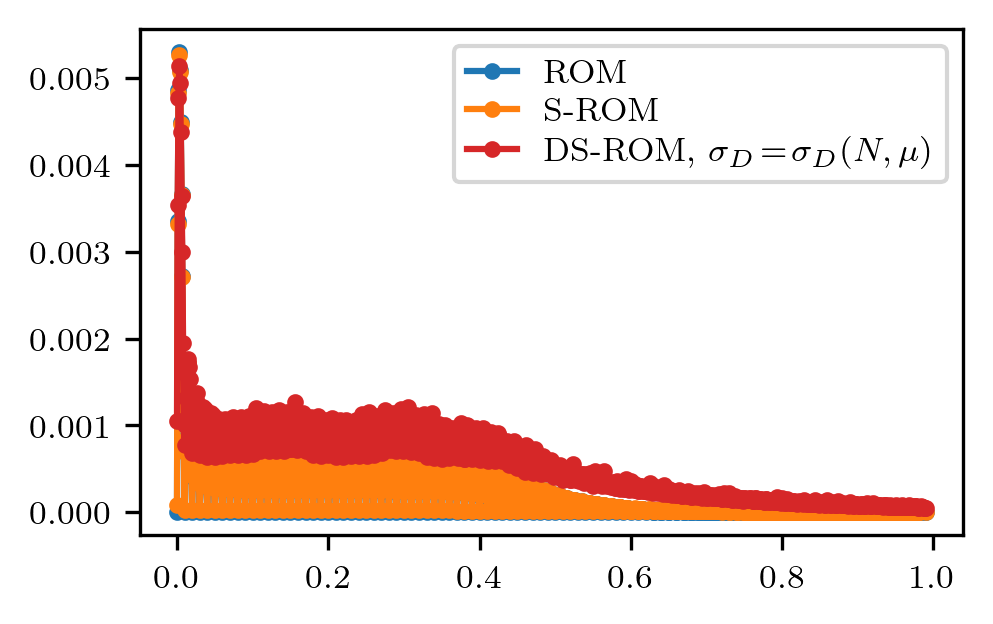

In [18]:
for i, rank in enumerate(ranks):
    case["sigma"], case["c"] = params_opt_best_coeff[i][0], params_opt_best_coeff[i][1]
    case["num_iter"] = 20
    jj = int(np.ceil(len(mu_val_all)/rank))
    # Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
    print(len(mu_val_all), np.arange(len(mu_val_all))[::jj])
    X_train = X_val_all[::jj]
    mu_train = mu_val_all[::jj, :]
    print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())
    # Restrict validation to mu <= max(mu_train)
    is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
    mu_val = mu_val_all[is_inside]
    X_val = X_val_all[is_inside]
    # Test: 20 random snapshots (constant seed)
    rng = np.random.default_rng(42)
    n_test_want = 20
    n_avail = len(mu_val)
    inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
    mu_test = mu_val[inds]
    X_test = X_val[inds]

    
    #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
    print(X_train.shape, X_test.shape, X_val.shape)
    print(mu_train.shape, mu_test.shape, mu_val.shape)
    
    case["mu_train"] = mu_train
    mean_ROM, mean_sROM, mean_sROMs, X_val_ROM, X_val_sROM, X_val_sROMs = target_function_best_coeff(case, X_train, mu_val, X_e=X_val)
    e_ROM = L2_error_rw(X_val_ROM, X_val)
    e_sROM = L2_error_rw(X_val_sROM, X_val)
    e_sROMs = L2_error_rw(X_val_sROMs, X_val)
    fig, ax = plt.subplots()
    ax.plot(mu_val.ravel(), e_ROM.ravel(), "C0o-", ms=3, label=r"ROM")
    ax.plot(mu_val.ravel(), e_sROM.ravel(), "C1o-", ms=3, label=r"S-ROM")
    ax.plot(mu_val.ravel(), e_sROMs.ravel(), "C3o-", ms=3, label=r"DS-ROM, $\sigma_D\!=\!\sigma_D(N, \mu)$")  #  (\sigma_S, c)
    plt.legend()
    plt.show()

# optimize n_iter too

In [19]:
# ranks = [10, 20, 30, 50, 100]
# params3_opt = [[None] for i in range(len(ranks))]

# for i, rank in enumerate(ranks):
#     jj = int(np.ceil(len(mu_val_all)/rank))
#     # Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
#     print(len(mu_val_all), np.arange(len(mu_val_all))[::jj])
#     X_train = X_val_all[::jj]
#     mu_train = mu_val_all[::jj, :]
#     print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())
#     # Restrict validation to mu <= max(mu_train)
#     is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
#     mu_val = mu_val_all[is_inside]
#     X_val = X_val_all[ is_inside]
#     # Test: 20 random snapshots (constant seed)
#     rng = np.random.default_rng(42)
#     n_test_want = 20
#     n_avail = len(mu_val)
#     inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
#     mu_test = mu_val_all[inds]
#     X_test = X_val_all[inds]
    
#     #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
#     print(X_train.shape, X_test.shape, X_val.shape)
#     print(mu_train.shape, mu_test.shape, mu_val.shape)
    
#     #rank = len(mu_train)
#    # print(rank, 2 * sigma_opt)
#     def _target2(params):
#         case["mu"] = mu_test
#         case["sigma"], case["c"] = params[0], params[1]
#         return target_function(case, X_e=X_test)[2]
    
#     def _target3(params):
#         case["mu"] = mu_test
#         case["sigma"], case["c"], case["num_iter"] = params[0], params[1], int(round(params[2]))
#         return target_function(case, X_e=X_test)[2]
#     sigma_opt = 0.23/rank
#     bounds2 = Bounds([0.001, 0], [2 * sigma_opt, 3])
#     bounds3 = Bounds([0.001, 0, 1], [5 * sigma_opt, 5, 200])
    
#     #bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 5, 200])
#     case["num_iter"] = 50
#     res = direct(_target3, bounds3, eps=1e-2, len_tol=0.01)
#     x_best = res["x"]
#     params3_opt[i] = x_best
#     case["sigma"], case["c"], case["num_iter"]  = x_best[0], x_best[1], int(round(x_best[2]))
#     target_function(case, X_e=X_test)
#     print("DIRECT result:", x_best, "mean_sROMs (min) =", res["fun"])




In [20]:
# for i, rank in enumerate(ranks):
#     case["sigma"], case["c"] = params3_opt[i][0], params3_opt[i][1]
#     case["num_iter"] = int(params3_opt[i][2])
#     jj = int(np.ceil(len(mu_val_all)/rank))
#     # Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
#     print(len(mu_val_all), np.arange(len(mu_val_all))[::jj])
#     X_train = X_val_all[::jj]
#     mu_train = mu_val_all[::jj, :]
#     print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())
#     # Restrict validation to mu <= max(mu_train)
#     is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
#     mu_val = mu_val_all[is_inside]
#     X_val = X_val_all[is_inside]
#     # Test: 20 random snapshots (constant seed)
#     rng = np.random.default_rng(42)
#     n_test_want = 20
#     n_avail = len(mu_val)
#     inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
#     mu_test = mu_val[inds]
#     X_test = X_val[inds]

    
#     #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
#     print(X_train.shape, X_test.shape, X_val.shape)
#     print(mu_train.shape, mu_test.shape, mu_val.shape)

#     case["mu"] = mu_val
#     mean_ROM, mean_sROM, mean_sROMs, X_val_ROM, X_val_sROM, X_val_sROMs = target_function(case, X_e=X_val)
#     e_ROM = L2_error_rw(X_val_ROM, X_val)
#     e_sROM = L2_error_rw(X_val_sROM, X_val)
#     e_sROMs = L2_error_rw(X_val_sROMs, X_val)
#     fig, ax = plt.subplots()
#     ax.plot(mu_val.ravel(), e_ROM.ravel(), "C0o-", ms=3, label=r"ROM")
#     ax.plot(mu_val.ravel(), e_sROM.ravel(), "C1o-", ms=3, label=r"S-ROM")
#     ax.plot(mu_val.ravel(), e_sROMs.ravel(), "C3o-", ms=3, label=r"DS-ROM, $\sigma_D\!=\!\sigma_D(N, \mu)$")  #  (\sigma_S, c)
#     plt.legend()
#     plt.show()